In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv(r"..\Dataset\cmi_internet.csv")
df.shape

(8460, 82)

In [4]:
len(df.columns)

82

In [5]:
for col in df.columns:
    print(col)

id
Basic_Demos-Enroll_Season
Basic_Demos-Age
Basic_Demos-Sex
CGAS-Season
CGAS-CGAS_Score
Physical-Season
Physical-BMI
Physical-Height
Physical-Weight
Physical-Waist_Circumference
Physical-Diastolic_BP
Physical-HeartRate
Physical-Systolic_BP
Fitness_Endurance-Season
Fitness_Endurance-Max_Stage
Fitness_Endurance-Time_Mins
Fitness_Endurance-Time_Sec
FGC-Season
FGC-FGC_CU
FGC-FGC_CU_Zone
FGC-FGC_GSND
FGC-FGC_GSND_Zone
FGC-FGC_GSD
FGC-FGC_GSD_Zone
FGC-FGC_PU
FGC-FGC_PU_Zone
FGC-FGC_SRL
FGC-FGC_SRL_Zone
FGC-FGC_SRR
FGC-FGC_SRR_Zone
FGC-FGC_TL
FGC-FGC_TL_Zone
BIA-Season
BIA-BIA_Activity_Level_num
BIA-BIA_BMC
BIA-BIA_BMI
BIA-BIA_BMR
BIA-BIA_DEE
BIA-BIA_ECW
BIA-BIA_FFM
BIA-BIA_FFMI
BIA-BIA_FMI
BIA-BIA_Fat
BIA-BIA_Frame_num
BIA-BIA_ICW
BIA-BIA_LDM
BIA-BIA_LST
BIA-BIA_SMM
BIA-BIA_TBW
PAQ_A-Season
PAQ_A-PAQ_A_Total
PAQ_C-Season
PAQ_C-PAQ_C_Total
PCIAT-Season
PCIAT-PCIAT_01
PCIAT-PCIAT_02
PCIAT-PCIAT_03
PCIAT-PCIAT_04
PCIAT-PCIAT_05
PCIAT-PCIAT_06
PCIAT-PCIAT_07
PCIAT-PCIAT_08
PCIAT-PCIAT_09
PCIAT-

In [6]:
df["sii"].notnull().sum()

np.int64(8460)

sii
0.0    5833
1.0    1587
2.0     952
3.0      88
Name: count, dtype: int64

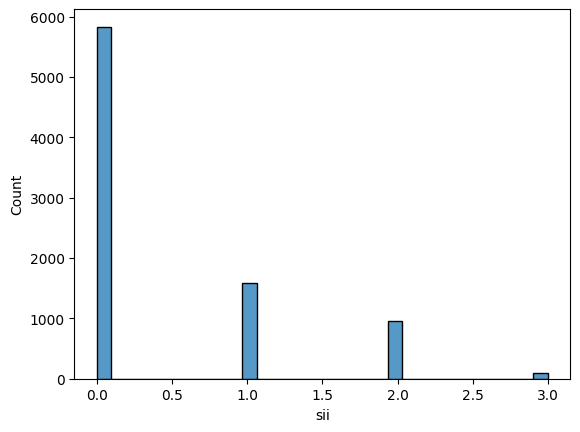

In [7]:
sns.histplot(df["sii"])
df["sii"].value_counts()

In [8]:
# df.drop(["id"], inplace=True, axis=1)
# df.shape

In [9]:
columns_with_missing_values = []
for col in df.columns:
    if df[col].isna().sum() > 0:
        columns_with_missing_values.append(col)

columns_with_missing_values.__len__()

77

In [10]:
# for col in df.columns:
#     plt.figure()
#     sns.histplot(df[col])
#     plt.plot()

## Ricerca di minimi e massimi

In [11]:
# Assuming your dataframe is already loaded as 'df'
# df = pd.read_csv('your_dataset.csv')

string_cols = [
    'Basic_Demos-Enroll_Season', 'CGAS-Season', 'Physical-Season', 
    'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_A-Season',
    'PAQ_C-Season', 'SDS-Season', 'PreInt_EduHx-Season'
]

domains = []
for col in df.columns:
    if col in string_cols:
        domains.append("")
    else:
        domains.append(f"[{df[col].min()}, {df[col].max()}]")

# Create a new dataframe with the results and save it
domain_df = pd.DataFrame({"Domain": domains}, index=df.columns)
domain_df.index.name = "Attribute"
domain_df.to_csv("actual_domains.csv")

## CSV statistiche

In [12]:
stats_list = []
total_rows = len(df)

for col in df.columns:
    missing = df[col].isnull().sum()
    n_val = total_rows - missing
    pct_missing = round((missing / total_rows) * 100, 2)
    
    stat_dict = {
        'Var': col,
        'N': n_val,
        'Missing': missing,
        '%Missing': pct_missing
    }
    
    if pd.api.types.is_numeric_dtype(df[col]):
        stat_dict.update({
            'Unique Values': '',
            'Top': '',
            'Freq': '',
            'Mean': round(df[col].mean(), 4) if n_val > 0 else '',
            'Std. Dev.': round(df[col].std(), 4) if n_val > 1 else '',
            '10%': round(df[col].quantile(0.10), 4) if n_val > 0 else '',
            '50%': round(df[col].quantile(0.50), 4) if n_val > 0 else '',
            '90%': round(df[col].quantile(0.90), 4) if n_val > 0 else ''
        })
    else:
        stat_dict.update({
            'Unique Values': df[col].nunique(),
            'Top': df[col].mode()[0] if n_val > 0 else '',
            'Freq': df[col].value_counts().iloc[0] if n_val > 0 else '',
            'Mean': '',
            'Std. Dev.': '',
            '10%': '',
            '50%': '',
            '90%': ''
        })
        
    stats_list.append(stat_dict)

stats_df = pd.DataFrame(stats_list)

cols_order = [
    'Var', 'N', 'Unique Values', 'Top', 'Freq', 
    'Mean', 'Std. Dev.', '10%', '50%', '90%', 
    'Missing', '%Missing'
]
stats_df = stats_df[cols_order]

stats_df.to_csv('descriptive_stats.csv', index=False)